<a href="https://colab.research.google.com/github/aiformedresearch/AI-for-Medicine-2024-25/blob/main/notebooks/roc_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ROC Curve: Simple Example

In this notebook, we illustrate how to construct a Receiver Operating Characteristic (ROC) curve using a simple dataset of 10 subjects.
Five are positive cases (`p`), and five are negative cases (`n`).
A simulated model assigns a score to each subject, and we examine how changing the threshold affects the classification.




## Step 1: Define the dataset
We define two toy datasets:

- `data_ideal`: a perfectly separable scenario where the model assigns very high scores to all positives and low scores to all negatives.
- `data_real`: a more realistic and noisy example with some overlap between positive and negative scores.

You can toggle between the two by assigning either `data_ideal` or `data_real` to the variable `data`.

The data is then loaded into a pandas DataFrame and displayed.

In [ ]:
import pandas as pd

# Define synthetic data: 10 subjects (5 positive, 5 negative)
data_ideal = {
    'Subject': [f'Subject {i+1}' for i in range(10)],
    'True Label': ['p', 'p', 'p', 'p', 'p', 'p', 'n', 'n', 'n', 'n'],
    'Model Score': [0.99999, 0.99999, 0.99993, 0.99986, 0.99964, 0.99955, 0.68139, 0.50961, 0.48880, 0.44951]
}

data_real = {
    'Subject': [f'Subject {i+1}' for i in range(20)],
    'True Label': ['p', 'p', 'n', 'p', 'p', 'p', 'n', 'n', 'p', 'n', 'p', 'n', 'p', 'n', 'n', 'n', 'p', 'n', 'p', 'n'],
    'Model Score': [0.9, 0.8, 0.7, 0.6, 0.55, 0.54, 0.53, 0.52, 0.51, 0.505, 0.4, 0.39, 0.38, 0.37, 0.36, 0.35, 0.34, 0.33, 0.30, 0.1]
}

#data = data_ideal
data = data_real

df = pd.DataFrame(data)
df

,Subject,True Label,Model Score
0,Subject 1,p,0.900
1,Subject 2,p,0.800
2,Subject 3,n,0.700
3,Subject 4,p,0.600
4,Subject 5,p,0.550
5,Subject 6,p,0.540
6,Subject 7,n,0.530
7,Subject 8,n,0.520
8,Subject 9,p,0.510
9,Subject 10,n,0.505


## Step 2: Convert labels and compute ROC
We convert the labels to binary (1 = positive, 0 = negative), then compute the ROC curve using `sklearn.metrics.roc_curve`.


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix

# Convert labels to binary
y_true = [1 if label == 'p' else 0 for label in df['True Label']]
y_scores = df['Model Score']

# Use all unique thresholds
all_thresholds = np.sort(np.unique(y_scores))[::-1]
fpr_list = []
tpr_list = []

# Compute initial point for threshold = +infinity (all predicted as 0)
y_pred_inf = [0 for _ in y_scores]  # no positives predicted
tn, fp, fn, tp = confusion_matrix(y_true, y_pred_inf).ravel()
fpr_list = [fp / (fp + tn)]
tpr_list = [tp / (tp + fn)]
all_thresholds = [np.inf]  # start list with infinity

# Add the rest of the thresholds
for thresh in np.sort(np.unique(y_scores))[::-1]:
    y_pred = [1 if score >= thresh else 0 for score in y_scores]
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    fpr = fp / (fp + tn) if (fp + tn) != 0 else 0
    tpr = tp / (tp + fn) if (tp + fn) != 0 else 0
    fpr_list.append(fpr)
    tpr_list.append(tpr)
    all_thresholds.append(thresh)

## Step 3: Plot the ROC Curve
We now visualize the ROC curve, showing the tradeoff between True Positive Rate (TPR) and False Positive Rate (FPR).


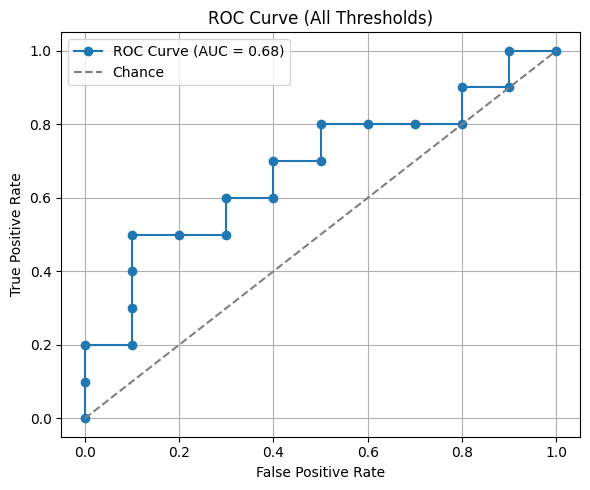

,Threshold,False Positive Rate,True Positive Rate
0,inf,0.0,0.0
1,0.900,0.0,0.1
2,0.800,0.0,0.2
3,0.700,0.1,0.2
4,0.600,0.1,0.3
5,0.550,0.1,0.4
6,0.540,0.1,0.5
7,0.530,0.2,0.5
8,0.520,0.3,0.5
9,0.510,0.3,0.6


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import auc

roc_auc = auc(fpr_list, tpr_list)

plt.figure(figsize=(6, 5))
plt.plot(fpr_list, tpr_list, marker='o', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (All Thresholds)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Create ROC table
roc_table = pd.DataFrame({
    'Threshold': all_thresholds,
    'False Positive Rate': fpr_list,
    'True Positive Rate': tpr_list
})
roc_table

## Step 4: Explore the effect of threshold interactively
Use the slider below to change the threshold and observe how predictions and confusion metrics change.


In [ ]:
from ipywidgets import interact

@interact(threshold=(0.0, 1.0, 0.05))
def show_confusion(threshold=0.5):
    y_pred = [1 if score >= threshold else 0 for score in y_scores]
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # Compute FPR and TPR manually
    fpr = fp / (fp + tn) if (fp + tn) != 0 else 0
    tpr = tp / (tp + fn) if (tp + fn) != 0 else 0

    # Print results
    print(f"Threshold: {threshold:.2f}")
    print(f"True Positives: {tp}")
    print(f"False Negatives: {fn}")
    print(f"False Positives: {fp}")
    print(f"True Negatives: {tn}")
    print(f"True Positive Rate (TPR): {tpr:.2f}")
    print(f"False Positive Rate (FPR): {fpr:.2f}")
    print("\nConfusion Matrix:")
    print(cm)

    # Plot ROC with dynamically computed TPR/FPR point
    plt.figure(figsize=(6, 5))
    plt.plot(fpr_list, tpr_list, label='ROC Curve')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
    plt.scatter(fpr, tpr, color='red', s=100, label=f'Threshold = {threshold:.2f}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve with Threshold Marker')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

interactive(children=(FloatSlider(value=0.5, description='threshold', max=1.0, step=0.05), Output()), _dom_cla…

## Summary
- The ROC curve is constructed by changing the threshold applied to the model's score.
- Each point on the curve corresponds to a specific threshold.
- The area under the curve (AUC) gives a scalar value representing the model's ability to distinguish between the two classes.
- The interactive slider allows exploration of classification results as a function of threshold.

You can explore how the curve would change by modifying the scores or the number of samples.
